# Distribution Optimization

Optimize finished-goods movement from plants to warehouses while satisfying demand, plant supply, and warehouse capacity constraints.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
warehouses = pd.read_csv(PROJECT_ROOT / "data/raw/warehouses.csv")
transport = pd.read_csv(PROJECT_ROOT / "data/raw/plant_warehouse_transport.csv")
warehouse_costs = pd.read_csv(PROJECT_ROOT / "data/raw/warehouse_costs.csv")
display(warehouses)
display(transport)

,warehouse_id,warehouse_name,region,capacity_cases
0,WH_Delhi,Delhi Warehouse,North,180000
1,WH_Mumbai,Mumbai Warehouse,West,200000
2,WH_Kolkata,Kolkata Warehouse,East,150000
3,WH_Bangalore,Bangalore Warehouse,South,180000
4,WH_Hyderabad,Hyderabad Warehouse,Central,140000


,plant_id,warehouse_id,cost_per_case
0,P01,WH_Delhi,2.0
1,P01,WH_Mumbai,6.0
2,P01,WH_Kolkata,5.0
3,P01,WH_Bangalore,7.0
4,P01,WH_Hyderabad,4.0
5,P02,WH_Delhi,7.0
6,P02,WH_Mumbai,5.0
7,P02,WH_Kolkata,6.0
8,P02,WH_Bangalore,2.0
9,P02,WH_Hyderabad,3.5


In [3]:
distribution_plan = pd.read_csv(PROJECT_ROOT / "data/processed/distribution_plan.csv", parse_dates=["week_start"])
display(distribution_plan.head(20))
network_summary = distribution_plan.groupby(["plant_id", "warehouse_id"], as_index=False).agg(cases=("shipment_cases", "sum"), cost=("distribution_cost", "sum")).sort_values("cases", ascending=False)
display(network_summary)

,plant_id,warehouse_id,sku,shipment_cases,transport_cost_per_case,handling_cost_per_case,week_start,distribution_cost
0,P01,WH_Delhi,BB1000,327.180340,2.0,1.2,2025-06-30,1046.977088
1,P01,WH_Delhi,BB250,171.717080,2.0,1.2,2025-06-30,549.494656
2,P01,WH_Delhi,BB500,256.825050,2.0,1.2,2025-06-30,821.840160
3,P01,WH_Delhi,EN250,101.953220,2.0,1.2,2025-06-30,326.250304
4,P01,WH_Delhi,EN500,82.808595,2.0,1.2,2025-06-30,264.987504
5,P01,WH_Delhi,LM250,126.916010,2.0,1.2,2025-06-30,406.131232
6,P01,WH_Delhi,LM500,207.699150,2.0,1.2,2025-06-30,664.637280
7,P01,WH_Delhi,OR1000,228.250870,2.0,1.2,2025-06-30,730.402784
8,P01,WH_Delhi,OR500,163.105900,2.0,1.2,2025-06-30,521.938880
9,P01,WH_Delhi,WT1000,504.841770,2.0,1.2,2025-06-30,1615.493664


,plant_id,warehouse_id,cases,cost
3,P02,WH_Mumbai,68778.360270,440181.505728
1,P02,WH_Bangalore,66271.278579,218695.219311
0,P01,WH_Delhi,60709.994695,194271.983024
5,P03,WH_Kolkata,57981.042358,179741.231310
2,P02,WH_Hyderabad,31987.988788,148744.147864
4,P03,WH_Hyderabad,22878.443896,94945.542168


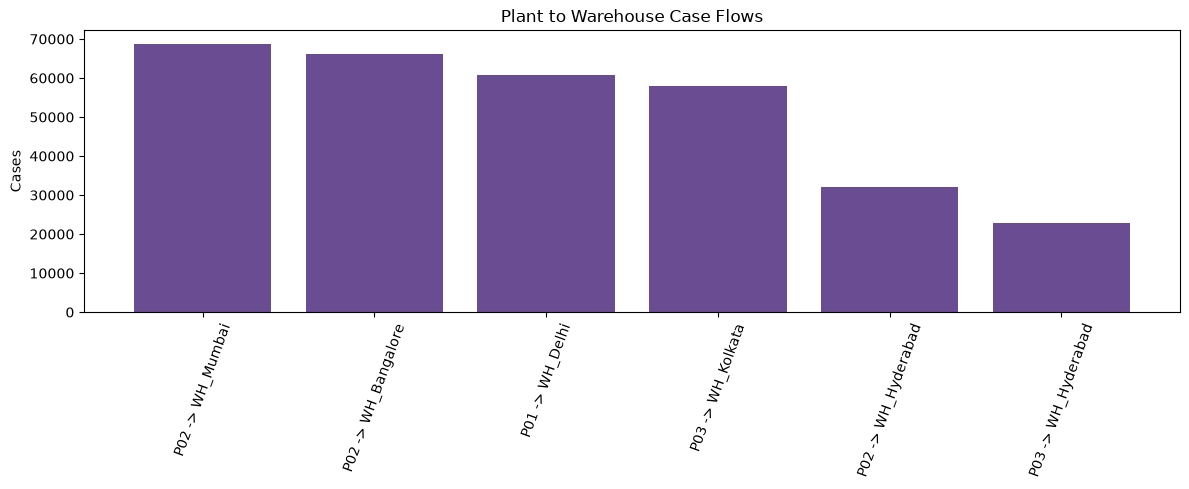

In [4]:
plt.figure(figsize=(12, 5))
labels = network_summary["plant_id"] + " -> " + network_summary["warehouse_id"]
plt.bar(labels, network_summary["cases"], color="#6a4c93")
plt.title("Plant to Warehouse Case Flows")
plt.ylabel("Cases")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

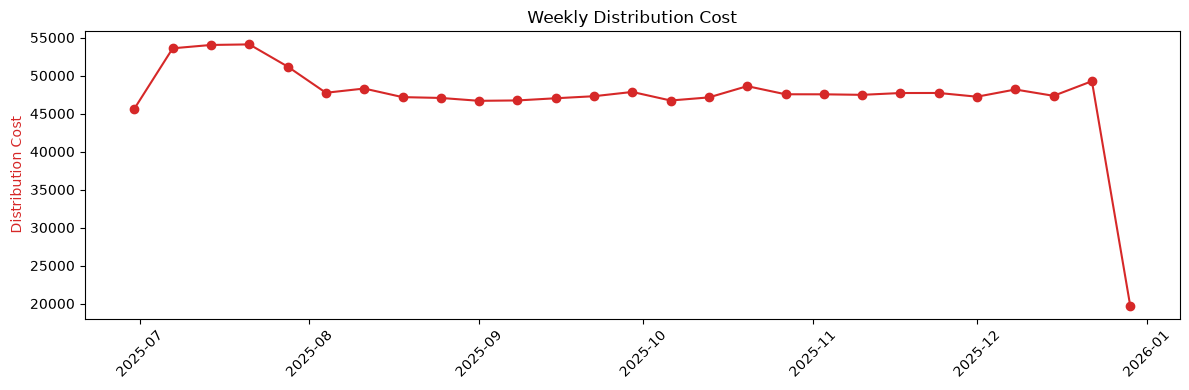

In [5]:
weekly_distribution_cost = distribution_plan.groupby("week_start", as_index=False).agg(cases=("shipment_cases", "sum"), cost=("distribution_cost", "sum"))
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(weekly_distribution_cost["week_start"], weekly_distribution_cost["cost"], color="#d62828", marker="o")
ax1.set_ylabel("Distribution Cost", color="#d62828")
ax1.set_title("Weekly Distribution Cost")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [7]:
%pip install pulp
from src.distribution.distribution_optimizer import calculate_distribution_kpis
total_cases, total_cost, avg_cost_per_case, plant_summary, warehouse_summary = calculate_distribution_kpis(distribution_plan)
print("Total cases:", round(total_cases, 2))
print("Total cost:", round(total_cost, 2))
print("Average cost per case:", round(avg_cost_per_case, 2))
display(plant_summary)
display(warehouse_summary)

  Using cached pulp-3.3.2-py3-none-any.whl.metadata (8.6 kB)
Using cached pulp-3.3.2-py3-none-any.whl (16.4 MB)
Note: you may need to restart the kernel to use updated packages.
Total cases: 308607.11
Total cost: 1276579.63
Average cost per case: 4.14



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,plant_id,cases_shipped,distribution_cost
0,P01,60709.994695,194271.983024
1,P02,167037.627637,807620.872902
2,P03,80859.486254,274686.773478


,warehouse_id,cases_received,distribution_cost
0,WH_Bangalore,66271.278579,218695.219311
1,WH_Delhi,60709.994695,194271.983024
2,WH_Hyderabad,54866.432684,243689.690032
3,WH_Kolkata,57981.042358,179741.231310
4,WH_Mumbai,68778.360270,440181.505728
